A portfolio consists of 100 obligors, with the first 50 having a
probability of default of 0.5%, and the remaining 50 having a
probability of default of 0.2%. The default events are indepen
dent among obligors. The LGD is 0.4 for the first group of
obligors and 0.3 for the second group.

The weight of a loan is 1/100, each obligor has exactly one loan.

What is the expected loss during this period? Furthermore, what would the loss distribution look like?
Simulate the process 2000 times and generate a plot based on the results.

In [33]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

np.random.seed(42)

In [12]:
N_SIMULATIONS = 2000
N_OBLIGORS    = 100
LOAN_WEIGHT   = 1 / N_OBLIGORS   # = 0.01  (jeder Kredit hat Gewicht 1/100)

# Gruppe 1: Obligor 0–49
PD_1  = 0.005   # 0,5 %
LGD_1 = 0.4

# Gruppe 2: Obligor 50–99
PD_2  = 0.002   # 0,2 %
LGD_2 = 0.3

In [14]:
# EL = Summe über alle Obligoren von (PD × LGD × Gewicht)
EL_group1 = 50 * PD_1 * LGD_1 * LOAN_WEIGHT
EL_group2 = 50 * PD_2 * LGD_2 * LOAN_WEIGHT
EL_total  = EL_group1 + EL_group2


print(f"  EL Gruppe 1 (PD=0,5%, LGD=0,4): {EL_group1:.6f}")
print(f"  EL Gruppe 2 (PD=0,2%, LGD=0,3): {EL_group2:.6f}")
print(f"  Gesamt-EL (analytisch):          {EL_total:.6f}")



  EL Gruppe 1 (PD=0,5%, LGD=0,4): 0.001000
  EL Gruppe 2 (PD=0,2%, LGD=0,3): 0.000300
  Gesamt-EL (analytisch):          0.001300


In [15]:
# Wahrscheinlichkeiten für jeden Obligor
pd_array  = np.array([PD_1] * 50 + [PD_2] * 50)
lgd_array = np.array([LGD_1] * 50 + [LGD_2] * 50)

defaults = np.random.binomial(n=1, p=pd_array, size=(N_SIMULATIONS, N_OBLIGORS))

losses = (defaults * lgd_array * LOAN_WEIGHT).sum(axis=1)

# Ergebnisse als DataFrame
df = pd.DataFrame({"loss": losses})

print(f"\n  Simulierter Mittelwert:    {df['loss'].mean():.6f}")
print(f"  Simulierte Standardabw.:   {df['loss'].std():.6f}")
print(f"  Simuliertes Maximum:       {df['loss'].max():.6f}")
print(f"  Anteil Null-Verlust-Sim.:  {(df['loss'] == 0).mean()*100:.1f} %")



  Simulierter Mittelwert:    0.001301
  Simulierte Standardabw.:   0.002187
  Simuliertes Maximum:       0.015000
  Anteil Null-Verlust-Sim.:  70.0 %


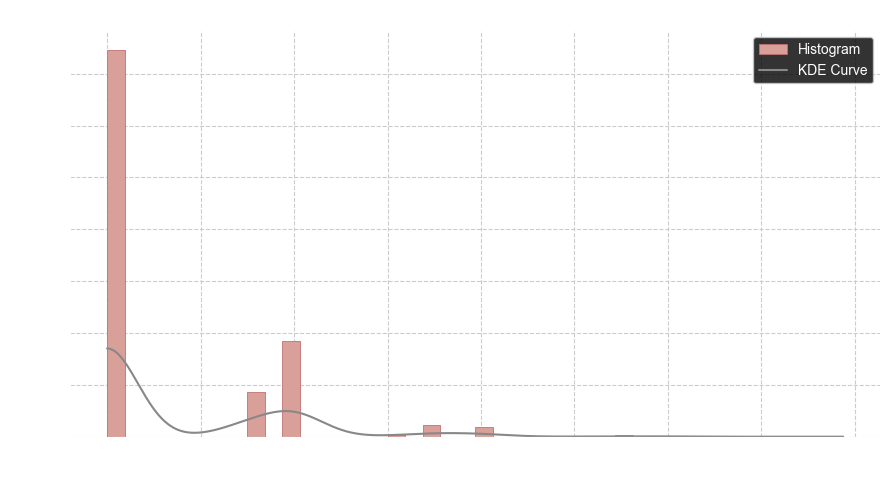

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Histogramm – density=True damit KDE auf gleicher Skala liegt
ax.hist(losses, bins=40, density=True,
        color="#d9a09a", edgecolor="#c07070",
        linewidth=0.6, label="Histogram")

# KDE-Kurve
kde = gaussian_kde(losses, bw_method=0.3)
x_vals = np.linspace(losses.min(), losses.max() * 1.05, 500)
ax.plot(x_vals, kde(x_vals), color="#888888", linewidth=1.5, label="KDE Curve")

# Achsen & Beschriftung
ax.set_xlabel("Total Loss", fontsize=11)
ax.set_ylabel("Density (Probability)", fontsize=11)
ax.set_title("Density Plot of Total Loss Across 2000 Simulations", fontsize=12)

# Gitter wie im Referenzbild (gestrichelt, hellgrau)
ax.grid(True, linestyle="--", color="#cccccc", linewidth=0.8)
ax.set_axisbelow(True)

ax.legend(fontsize=10)

plt.tight_layout()
plt.show()



Die X-Achse zeigt den Gesamtverlust des Portfolios (als Dezimalzahl, z.B. 0.004 = 0,4 % des Portfolios). Die Y-Achse zeigt die Dichte, also wie häufig ein bestimmter Verlust in den 2000 Simulationen aufgetreten ist.

Der große Balken ganz links (bei ~0.0000)
Das ist das auffälligste Merkmal. In ca. 70 % aller Simulationen trat kein einziger Ausfall auf — der Verlust war also null. Das macht Sinn, weil die Ausfallwahrscheinlichkeiten sehr niedrig sind (0,5 % und 0,2 %).

Die kleineren Balken rechts davon
Diese zeigen Szenarien, in denen 1, 2 oder mehr Obligoren ausgefallen sind. Je weiter rechts ein Balken liegt, desto mehr Ausfälle sind gleichzeitig passiert — und desto seltener ist das.

Die graue KDE-Kurve
Die Kurve glättet das Histogramm und macht den rechten Schwanz der Verteilung besser sichtbar. Man erkennt: Die Verteilung fällt nach rechts langsam ab — hohe Verluste sind möglich, aber sehr selten.